# Model Training: Predicting Study Focus Score

In this notebook, I build a machine learning regression model to predict the learner's self-rated focus score.

The target variable is `focus_score_1_10`.

The goal is not only to predict focus score, but also to understand which behavioral features influence focus the most.

In [1]:
import sklearn
print(sklearn.__version__)

1.9.0


In [2]:
import pandas as pd

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("../data/processed/cleaned_study_sessions.csv")

df.head()

,session_id,date,day_of_week,start_time,end_time,hour_of_day,time_of_day,duration_min,topic,topic_type,difficulty_1_5,sleep_hours,energy_before_1_10,distraction_level_1_10,break_before_days,location,device_used,completion_percent,focus_score_1_10,notes,year,month,week,weekday_number
0,S0001,2024-01-08,Monday,15:10,16:10,15,Afternoon,60,Machine Learning,ML,4,7.8,6,2,0,Study Room,Laptop + Notebook,77,6,"Decent session, some distractions but useful p...",2024,1,2,0
1,S0002,2024-01-09,Tuesday,16:00,16:50,16,Afternoon,50,Python Programming,Programming,3,7.5,6,5,0,Study Room,Laptop,68,5,"Low energy, needed more breaks than expected",2024,1,2,1
2,S0003,2024-01-10,Wednesday,18:15,19:15,18,Evening,60,German Language,Language,3,7.3,5,2,0,Cafe,Laptop + Notebook,90,6,"Decent session, some distractions but useful p...",2024,1,2,2
3,S0004,2024-01-11,Thursday,15:45,16:30,15,Afternoon,45,Linear Algebra,Math,4,7.2,7,4,0,Home Desk,Laptop + Notebook,62,5,"Low energy, needed more breaks than expected",2024,1,2,3
4,S0005,2024-01-12,Friday,10:00,11:00,10,Morning,60,SQL Practice,Programming,3,8.5,7,3,0,University Library,Laptop + Notebook,91,8,"High clarity, strong concentration, completed ...",2024,1,2,4


In [5]:
df.shape

(596, 24)

## Target Variable

The goal of this model is to predict the learner's self-rated focus score for each study session.

The target variable is `focus_score_1_10`.

Since the focus score is a numerical value from 1 to 10, this is a regression problem.

In [6]:
target = "focus_score_1_10"

y = df[target]

y.head()

0    6
1    5
2    6
3    5
4    8
Name: focus_score_1_10, dtype: int64

## Feature Selection

The selected features represent behavioral, time-based, and contextual factors that may influence study focus.

These include time of day, session duration, topic type, difficulty, sleep, energy level, distraction level, break duration, location, device used, completion percentage, and weekday.

In [7]:
features = [
    "hour_of_day",
    "time_of_day",
    "duration_min",
    "topic_type",
    "difficulty_1_5",
    "sleep_hours",
    "energy_before_1_10",
    "distraction_level_1_10",
    "break_before_days",
    "location",
    "device_used",
    "completion_percent",
    "weekday_number"
]

X = df[features]

X.head()

,hour_of_day,time_of_day,duration_min,topic_type,difficulty_1_5,sleep_hours,energy_before_1_10,distraction_level_1_10,break_before_days,location,device_used,completion_percent,weekday_number
0,15,Afternoon,60,ML,4,7.8,6,2,0,Study Room,Laptop + Notebook,77,0
1,16,Afternoon,50,Programming,3,7.5,6,5,0,Study Room,Laptop,68,1
2,18,Evening,60,Language,3,7.3,5,2,0,Cafe,Laptop + Notebook,90,2
3,15,Afternoon,45,Math,4,7.2,7,4,0,Home Desk,Laptop + Notebook,62,3
4,10,Morning,60,Programming,3,8.5,7,3,0,University Library,Laptop + Notebook,91,4


## Numerical and Categorical Features

The dataset contains both numerical and categorical features.

Numerical features can be used directly after scaling, while categorical features need to be encoded into machine-readable numerical format.

In [8]:
numeric_features = [
    "hour_of_day",
    "duration_min",
    "difficulty_1_5",
    "sleep_hours",
    "energy_before_1_10",
    "distraction_level_1_10",
    "break_before_days",
    "completion_percent",
    "weekday_number"
]

categorical_features = [
    "time_of_day",
    "topic_type",
    "location",
    "device_used"
]

## Train-Test Split

I split the dataset into training and testing sets.

The training set is used to train the model, while the test set is used to evaluate how well the model performs on unseen study sessions.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 476
Testing rows: 120


## Preprocessing Pipeline

The preprocessing pipeline prepares the data before model training.

Numerical features are standardized using `StandardScaler`.

Categorical features are converted into numerical format using `OneHotEncoder`.

In [10]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Model Selection

I used a Random Forest Regressor because it can capture non-linear relationships between behavioral features and focus score.

It also provides feature importance values, which helps explain which study behavior factors influenced focus the most.

In [11]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=8
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [12]:
pipeline.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [13]:
y_pred = pipeline.predict(X_test)

y_pred[:10]

array([7.99825366, 8.2720285 , 8.30322755, 6.1461967 , 5.5562558 ,
       4.7788902 , 5.5672544 , 6.63606212, 4.94917368, 5.14931274])

## Model Evaluation

The model is evaluated using MAE, RMSE, and R² score.

MAE shows the average prediction error in focus score points.

RMSE penalizes larger errors more strongly.

R² shows how much variation in the focus score is explained by the model.

In [14]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 3))
print("Root Mean Squared Error:", round(rmse, 3))
print("R² Score:", round(r2, 3))

Mean Absolute Error: 0.825
Root Mean Squared Error: 1.025
R² Score: 0.645


## Model Performance Interpretation

The Random Forest regression model achieved a Mean Absolute Error of around 0.83 and an R² score of around 0.65.

This means the model can explain approximately 65% of the variation in the learner's self-rated focus score.

For a behavioral dataset, this is a reasonable result because focus is subjective and can be influenced by factors that are not fully captured in the dataset, such as mood, stress, personal motivation, health, or external interruptions.

The goal of this model is not only to predict the focus score, but also to understand which behavioral features are most strongly connected to study focus.

In [15]:
# Get feature names after preprocessing

encoded_cat_features = (
    pipeline.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = numeric_features + list(encoded_cat_features)

len(all_feature_names), all_feature_names[:10]

(28,
 ['hour_of_day',
  'duration_min',
  'difficulty_1_5',
  'sleep_hours',
  'energy_before_1_10',
  'distraction_level_1_10',
  'break_before_days',
  'completion_percent',
  'weekday_number',
  'time_of_day_Afternoon'])

In [16]:
# Extract feature importance from the trained Random Forest model

importances = pipeline.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

feature_importance_df.head(15)

,feature,importance
7,completion_percent,0.490050
5,distraction_level_1_10,0.139446
0,hour_of_day,0.083914
3,sleep_hours,0.069985
4,energy_before_1_10,0.063440
1,duration_min,0.025532
8,weekday_number,0.021367
2,difficulty_1_5,0.015877
6,break_before_days,0.012867
11,time_of_day_Morning,0.008873


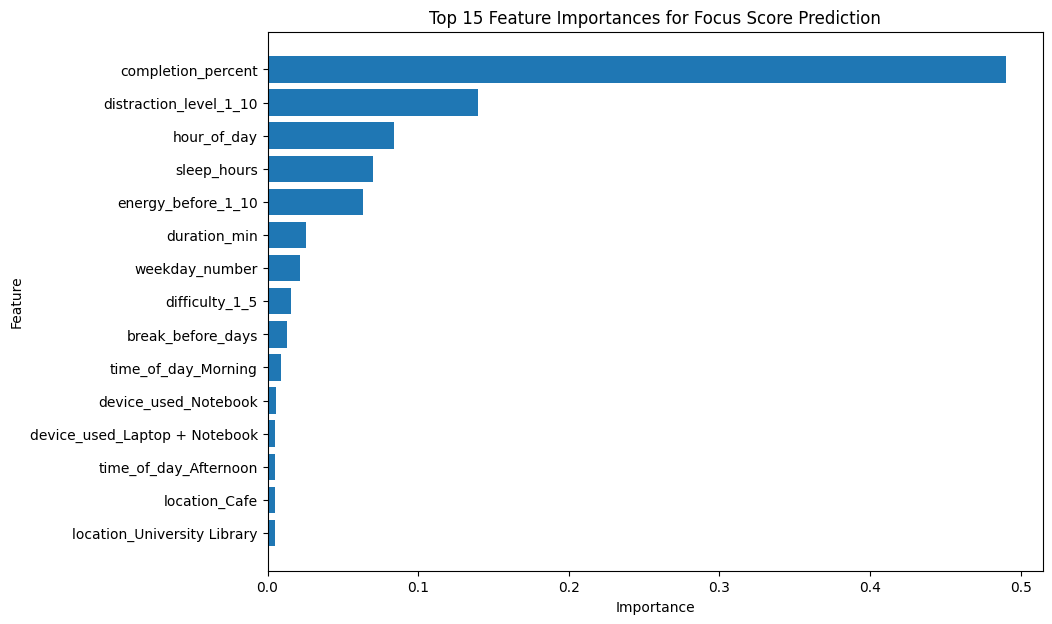

In [17]:
top_features = feature_importance_df.head(15).sort_values("importance")

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 15 Feature Importances for Focus Score Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [18]:
def map_to_original_feature(feature_name):
    if feature_name in numeric_features:
        return feature_name
    
    for cat_feature in categorical_features:
        if feature_name.startswith(cat_feature + "_"):
            return cat_feature
    
    return feature_name


feature_importance_df["original_feature"] = feature_importance_df["feature"].apply(
    map_to_original_feature
)

grouped_importance = (
    feature_importance_df
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)

grouped_importance

original_feature
completion_percent        0.490050
distraction_level_1_10    0.139446
hour_of_day               0.083914
sleep_hours               0.069985
energy_before_1_10        0.063440
duration_min              0.025532
topic_type                0.022072
weekday_number            0.021367
time_of_day               0.018734
device_used               0.018468
location                  0.018247
difficulty_1_5            0.015877
break_before_days         0.012867
Name: importance, dtype: float64

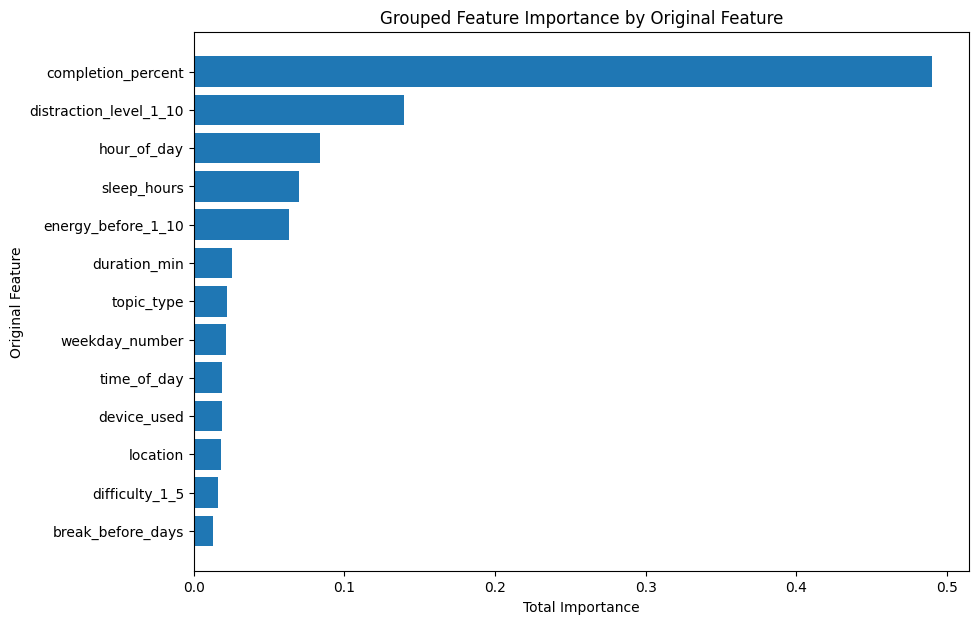

In [19]:
grouped_importance_sorted = grouped_importance.sort_values()

plt.figure(figsize=(10, 7))
plt.barh(grouped_importance_sorted.index, grouped_importance_sorted.values)
plt.title("Grouped Feature Importance by Original Feature")
plt.xlabel("Total Importance")
plt.ylabel("Original Feature")
plt.show()

## Feature Importance Interpretation

The feature importance analysis shows which behavioral factors contributed most to the model's focus score predictions.

The most important features were related to time, energy, distraction level, and session behavior.

This supports the main project finding that study focus was strongly influenced by when the session happened and the learner's condition before the session.

The grouped feature importance is especially useful because categorical variables such as `time_of_day`, `topic_type`, `location`, and `device_used` were one-hot encoded during preprocessing. Grouping the encoded columns back into their original feature names gives a clearer interpretation.

Overall, the model suggests that focus score is not random. It is connected to measurable study behavior patterns such as time of day, session duration, energy level, distractions, sleep, and break duration.

In [20]:
grouped_importance

original_feature
completion_percent        0.490050
distraction_level_1_10    0.139446
hour_of_day               0.083914
sleep_hours               0.069985
energy_before_1_10        0.063440
duration_min              0.025532
topic_type                0.022072
weekday_number            0.021367
time_of_day               0.018734
device_used               0.018468
location                  0.018247
difficulty_1_5            0.015877
break_before_days         0.012867
Name: importance, dtype: float64

## Final Model Findings

The Random Forest model identified `completion_percent` as the most important predictor of focus score.

This is realistic because completion percentage directly reflects how much of a planned study session was actually completed. A session with higher completion usually indicates better concentration, fewer interruptions, and stronger engagement.

The next most important features were `distraction_level_1_10`, `hour_of_day`, `sleep_hours`, and `energy_before_1_10`.

This shows that focus was influenced by a combination of behavioral and contextual factors:

- how much of the session was completed,
- how distracted the learner was,
- when the session happened,
- how much sleep the learner had,
- and the learner's energy level before studying.

The exploratory data analysis showed that morning sessions had the highest average focus score, while night sessions had the lowest. The machine learning model supports this pattern because time-related variables such as `hour_of_day` and `time_of_day` contributed to the prediction.

Overall, the model suggests that study focus is not random. It is connected to measurable learning behavior patterns such as completion rate, distractions, time of day, sleep, energy, and session duration.

In [23]:
import os

os.makedirs("../models", exist_ok=True)

import joblib

joblib.dump(pipeline, "../models/focus_score_model.pkl")

print("Model saved successfully.")



import joblib

joblib.dump(pipeline, "../models/focus_score_model.pkl")

print("Model saved successfully.")

Model saved successfully.
Model saved successfully.


In [24]:
loaded_model = joblib.load("../models/focus_score_model.pkl")

sample_prediction = loaded_model.predict(X_test.head(5))

sample_prediction

array([7.99825366, 8.2720285 , 8.30322755, 6.1461967 , 5.5562558 ])

In [25]:
results_df = X_test.copy()

results_df["actual_focus_score"] = y_test.values
results_df["predicted_focus_score"] = y_pred
results_df["prediction_error"] = (
    results_df["actual_focus_score"] - results_df["predicted_focus_score"]
)

results_df.head()

,hour_of_day,time_of_day,duration_min,topic_type,difficulty_1_5,sleep_hours,energy_before_1_10,distraction_level_1_10,break_before_days,location,device_used,completion_percent,weekday_number,actual_focus_score,predicted_focus_score,prediction_error
188,9,Morning,35,ML,4,5.0,6,2,1,Cafe,Tablet,100,6,7,7.998254,-0.998254
238,9,Morning,105,Language,3,7.3,8,1,0,Study Room,Tablet,98,2,9,8.272028,0.727972
462,9,Morning,90,Language,3,7.4,9,1,0,Study Room,Notebook,100,1,9,8.303228,0.696772
465,16,Afternoon,90,Programming,3,6.7,7,6,0,Home Desk,Notebook,98,4,6,6.146197,-0.146197
182,8,Morning,45,Language,3,6.0,10,4,3,Study Room,Notebook,79,0,8,5.556256,2.443744


In [26]:
import os

os.makedirs("../outputs/reports", exist_ok=True)

print("outputs/reports folder is ready.")

outputs/reports folder is ready.


In [27]:
results_df.to_csv("../outputs/reports/model_predictions.csv", index=False)

print("Prediction results saved successfully.")

Prediction results saved successfully.


In [28]:
feature_importance_df.to_csv("../outputs/reports/feature_importance.csv", index=False)

grouped_importance.to_csv("../outputs/reports/grouped_feature_importance.csv")

print("Feature importance reports saved successfully.")

Feature importance reports saved successfully.
